# $\Delta H(p)$ display for constellations

In this notebook we compare the relative populations of gaps $w_{s,J}(\lambda)$ to samples of the populations
of gaps across the intervals of survival 
$$\Delta H(p_k) = [p_k^2, p_{k+1}^2]$$
We compare these actual counts to estimates made from the $w_{s,J}(\lambda)$.

For the models $w_{s,J}(p_k^\#)=w_{s,J}(\lambda)$ of relative populations, we use $p_0=37$.
The parameter
$$\lambda(p_k) = \prod_{p=41}^{p_k} \frac{p-J-2}{p-J-1} $$
So we create an array of values of $\lambda$ associated with the primes covered by 
$\mathcal{G}(23^\#)$ for $p_0 = 37$.  The minimum value under this range is
$$ \lambda(p_k=223092827) = 0.19416057 $$

The code in <i>12_DelHprep.ipynb</i> prepares the $\Delta H(p_k)$ samples.  Here we read that data and provide an interactive
display for comparing the sampled data to the estimates.



In [1]:
%reset -f

import pandas as pd
import numpy as np
from numpy.polynomial.polynomial import polyval
import array
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pickle

import gc
import psutil
import sys

import itertools
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display
plt.ion


<function matplotlib.pyplot.ion() -> 'AbstractContextManager'>

In [2]:
# import the class AdmS for admissible constellations
# from a20s_class import AdmS
# import the dictionaries for the constellations of interest
from a20s_class import J3dict
from a20s_class import J5dict

from a20s_class import J3keyarr
from a20s_class import J5keyarr


## Loading the array of primes and the array for $\lambda$
We will be comparing actual counts $N_\Delta$ of gaps in the intervals of survival
$$\Delta H(p_k) \; = \; [p_k^2,\; p_{k+1}^2],$$
across several sampled intervals of survival, to the estimated populations from the relative population models
$w_{s,J}(\lambda)$.

We load the small primes to track $p_k$, and to lookup the $\lambda$ corresponding to $p_k$ we load the array <i>lambda37[]</i>.
For our relative population models $w_{s,J}(\lambda)=w_{s,J}(p_k^\#)$ we start at $p_0=37$.  So $\lambda=1$ for $p_0=37$
and then
$$ \lambda(p_k) \; = \; \prod_{41}^{p_k} \frac{p-J-2}{p-J-1}$$

In [3]:
# we use primesE9 as the range for pk
# The interval of survival Delta-H(pk) goes from (pk)^2 to (p{k+1})^2
smallprimes = np.load('primesE9.npy')


In [4]:
# block to check the available system memory
gc.collect()
memory = psutil.virtual_memory()
available_memory = memory.available
del memory
print(f"Available memory: {available_memory / (1024 ** 2):.2f} MB")

Available memory: 3613.03 MB


In [5]:
lensmallprimes = len(smallprimes)
maxsmallprime = smallprimes[-1]
print(f"Length primes {lensmallprimes}  maxp {maxsmallprime} maxhorizon {maxsmallprime**2}")
# These values= primes 51961553  maxp 1023094327 maxhorizon 1046722001939582929

Length primes 51961884  maxp 1023101273 maxhorizon 1046736214814220529


In [6]:
# load the values of lambda calculated in previous notebook
# XXXQHERE:  try and except - message and end
# The parameter lambda37 starts at p0=37 with value 1
lambda37 = np.load('lambdaJ3E9.npy')
lambda37[0:12], lambda37[-12:]

(array([1.        , 0.97297297, 0.94802495, 0.92597786, 0.90708035,
        0.89058798, 0.87496363, 0.86107532, 0.84822345, 0.83593035,
        0.82478462, 0.8143443 ]),
 array([0.17773625, 0.17773625, 0.17773625, 0.17773625, 0.17773625,
        0.17773625, 0.17773625, 0.17773625, 0.17773625, 0.17773625,
        0.17773625, 0.17773625]))

In [7]:
# We use smallprimes array and the corresponding lambda array to estimate Merten's constant
# for this parameter
taildex = min(lensmallprimes-20, len(lambda37)-6)
MertensC = lambda37[taildex-10]* np.log(smallprimes[taildex])
MertensC

np.float64(3.687334730411479)

## Estimates from the models $w_s(p^\#)=w_s(\lambda)$
Here we prepare estimates of the expected counts of gaps, based on the models $w_s(p^\#)$.  The graph below will superimpose these estimates on the actual counts over sampled intervals of survival $\Delta H(p_k)$.

The hypothesis underlying our estimates is that the gaps in $\mathcal{G}(p^\#)$ are roughly distributed uniformly across the cycle.

The <b>first-order estimate</b> is simply that the number of gaps in an interval of survival should be proportional to
that gap's relative population at that point in the sieve:
$$ n_s (\Delta H) / n_{242}(\Delta H) \; \approx \; w_{s,3}(\lambda)$$

A <b>second-order improvement</b> can be made, by noting that in the horizon of survival $[q,q^2]$,
the gaps in the interval $[q,p^2]$ for $p < q$ were fixed by previous recursions across the cycles, 
and that especially those gaps to the left of this interval will reflect the distributions 
from much earlier in the evolution.
$$ n_g(\Delta H(q)) / n_{242}(\Delta H(q)) \; \approx \; w_{s,3}(q^\#) + \frac{p^2}{q^2-p^2} \Delta w$$

Since we use $p_0=37$ we can specify models for the relative populations $w_{s,J}(p_k^\#)$ for a few constellations of lengths
$J=3$ and $J=5$.  In general 
this bound is $g \le 2p_1$, and we have to handle the boundary case $g=2p_1$ separately.
$$ w_{s,J}(p_k^\#) \; = \; w_{s,J}(\infty) - l_2 \cdot \prod_{p_1}^{p_k} \frac{p-J-2}{p-J-1} + l_3 \cdot \prod_{p_1}^{p_k} \frac{p-J-3}{p-J-1} \cdots $$
where the coefficients $l_j$ are the dot-products of the corresponding left eigenvector $L_j^T$ with the vector of initial
relative populations $w_{s,J}(p_0^\#)$ for the gap $g$ and all of its driving terms in the cycle ${\mathcal G}(p_0^\#)$
$$l_j = L^T_j \cdot w_s(p_0^\#)$$
The asymptotic relative population for $s$ compared to other constellations is 
$$w_{s,J}(\infty) \; = \; L_1^T\cdot w_s(p_0^\#) \; = \; \sum_{j\ge J} w_{s,j}(p_0^\#)$$

We load the matrix of coefficients $l_j(s)$ from file.

In [8]:
# The matrix of coefficients lj is created in the '20_ws' notebook.  Here we read the results from file.
# These coefficients do not include the alternating signs
# check read from pickled file
with open('J3lj.pkl',"rb") as fp2:
    J3lj = pickle.load(fp2)
fp2.close()

# read in the coefficients for J=5
with open('J5lj.pkl',"rb") as fp2:
    J5lj = pickle.load(fp2)
fp2.close()

len(J3lj), len(J5lj)

# The coefficients are held in dictionaries, with the keys given in J3keyarr and J5keyarr


(21, 12)

In [28]:
J3lj['2,10,2']

array([2.66666667, 1.11491334])

## Preparing for the comparison of sampled populations to estimates
We provide an interactive histogram of the data sampled from several intervals $\Delta H(p)$.  The following steps comprise 
an outer loop for the interactive figure.
1. The user selects a file containing a data sample.  This is done indirectly through selecting the value of $\lambda$
2. We load the sample $\Delta H(p)$ from this file.
3. We determine the parameters ${\rm lowp}$ and ${\rm highp}$ such that the sample includes $\Delta H(p)$ 
for all ${\rm lowp} \le p \le {\rm highp}$.



In [9]:
# Initialize master lists of colors
# we set colors by family, as determined by winf(s)

redlist=['#FF0000', '#AF3235', '#F282B4', '#EC008C', '#ED135A', '#E08080']
greenlist=['#00FF00', '#009B55', '#8DC73E', '#008B72', '#3FBC9D', '#A0D0A0']
bluelist=['#0000FF', '#00B0F0', '#00B3B8', '#006795', '#A0A0D0', '#46C5DD']
orangelist=['#F7965A', '#F26035', '#FAA21A', '#F89E7B', '#F0A080', '#D0B080']
misclist=['#02268F','#8C368C', '#AF72B0']

# Define a master color dictionary - up to g=100
# we set colors by family, as determined by prime factors of the gap
# These will be used to color the bands in the histograms: g= p_k - p_{k-1}
mastercolordict={'2':'#FF0000', '4':'#FF8888', '8':'#EEBBBB', '16':'#FF99CC', '32':'#FFDDDD', '64':'#FFEEEE',
                 '6':'#0000FF', '12':'#00DDFF', '18':'#6666FF', '24':'#BBBBFF', '36':'#DDDDFF', '48':'#0000AF',
                 '54':'#44448F', '72':'#88888F',
                 '10':'#00CC00', '20':'#98FB98', '40':'#DDFFCF', '50':'#BBFFBB', '80':'#44AA66', '100':'#228F3F',
                 '30':'#FFD700', '60':'#FFB000', '90':'#FFCC33',
                 '14':'#DD00EE', '28':'#AA22CC', '56':'#660066', '98':'#662266',
                 '42':'#0088BB', '84':'#4488BB', '70':'#00BB88', 
                 '22':'#884400', '44':'#884444', '66':'#884488', '88':'#AA6644',
                 '26':'#AAAAAA', '52':'#888888', '78':'#6666AA',
                 '34':'#CC0000', '68':'#CC4444', '38':'#AA8800', '76':'#AA9944'}

In [10]:
smallprimes[10]

np.int64(37)

## Notes on samples of primes

| filename | num primes | $\min P$ | $\max P$ | $\# \Delta H$ | $\Delta H(p_0)$ | $\min P$ | $\Delta H(q_k)$ | $\max P$ |
| :--- | ---: | ---: | ---: | :---: | ---: | ---: | ---: | ---: |
| primeblockE09_360.npy | $55008596$ | $2400255059$ |$3600255031$ | $1021$ | $49003$ | $2401294057$ | $59981$ | $3599879993$ |
| primeblockE09_900.npy | $78902338$ | $7200254309$ |$9000254779$ | $881$ | $84857$ | $7200710471$ | $94847$ | $8996332747$ |
| primeblockE09_960.npy | $52355884$ | $8400254153$ |$9600254149$ | $557$ | $91673$ | $8403938941$ | $97967$ | $9598708711$ |
| primeblockE10_108.npy | $52072153$ | $9600254077$ | $10800254051$ | $506$ |$97987$ | $9601452193$|  $103913$ | $10799158553$ |
| primeblockE11_640.npy | $66214780$ | $6.400E11$ | $6.400E11$ | $94$ |$800011$ | $640017600137$|  $801103$ | $641772425447$ |
| primeblockE12_742.npy | $50612312$ | $7.421E12$ |$7.422E12$ | $18$ | $2724109$ | $7420769843911$ | $2724367$ | $7422230038127$ |
| primeblockE13_668.npy | $50267204$ | $6.679E13$ |$6.679E13$ | $7$ | $8172391$ | $66787974656917$ | $8172487$ | $66789543765101$ |
| primeblockE14_568.npy | $105954508$ | $5.677E14$ |$5.677E14$ | $7$ | $23826527$ | $567703388881771$ | $23826587$ | $567706819906781$ |
| primeblockE15_169.npy | $51337046$ | $1.694E15$ |$1.694E15$ | $1$ | $41161829$ | $1694296166625301$ | $41161829$ | $1694297813098769$ |
| primeblockE17_200.npy | $135549263$ | $2.00E17$ |$2.00E17$ | $2$ | $447216097$ | $200002237415913437$ | $447216101$ | $200002242782506531$ |
| primeblockE18_1046twin.npy | $130135262$ | $1.046E18$ | $1.046E18$ | $1$ |$1023094199$ | $1046721740027451601$|  $1023094201$ | $1046721744119828377$ |


## values of $\lambda(p_k)$
The parameter $\lambda$ is the subdominant eigenvalue in the discrete dynamic system.
$$ \lambda(p_k) \; = \; \prod_{p_1}^{p_k} \frac{p-J-2}{p-J-1}$$
This parameter is shared by all constellations of length $J$ but varies with the length $J$.

| filename |  $\min P$ | $\max P$ | $\lambda_g$ | $\lambda_{J3}$ | $\lambda_{J5}$ |
| :--- | ---: | ---: | ---: | ---: | ---: | 
| primeblockE09_360.npy | $49003$ | $59981$ | $0.339 - 0.3455$ | $0.335 - 0.3413$ | $0.331 - 0.3370$ |
| primeblockE09_900.npy | $84857$ | $94847$ | $0.326 - 0.3288$ | $0.322 - 0.3248$ | $0.318 - 0.3206$ |
| primeblockE09_960.npy | $91673$ | $97967$ | $0.325 - 0.3266$ | $0.321 - 0.3226$ | $0.317 - 0.3185$ |
| primeblockE10_108.npy |$97987$ | $103913$ | $0.323 - 0.3247$ | $0.319 - 0.3208$ | $0.315 - 0.3166$ |
| primeblockE11_640.npy |$800011$ | $801103$ | $0.27457$ | $0.27126$ | $0.26777$ |
| primeblockE12_742.npy | $2724109$ | $2724367$ | $0.25188$ | $0.24884$ | $0.24564$ |
| primeblockE13_668.npy | $8172391$ | $8172487$ | $0.23450$ | $0.23167$ | $0.22869$ |
| primeblockE14_568.npy | $23826527$ | $23826587$ | $0.21973$ | $0.21707$ | $0.21428$ |
| primeblockE15_169.npy | $41161829$ | $41161829$ | $0.21287$ | $0.21031$ | $0.20760$ |
| primeblockE17_200.npy | $447216097$ | $447216101$ | $0.18738$ | $0.18512$ | $0.18274$ |
| primeblockE18_1046twin.npy | $1023094199$ | $1023094201$ | $0.17991$ | $0.17774$ | $0.17545$ |


In [34]:
# Comparison of lambda values for the sampled intervals DH, for lengths J=1, J=3, J=5
ip = 0
targetprimes=np.array([59981,94847,97967,103913,801103,2724367,8172487,23826587,41161829,447216101,1023094201])
i=11
lamref = 1
lamval3 = 1
lamval5 = 1
while (ip < len(targetprimes)):
    while (smallprimes[i] <= targetprimes[ip]):
        lamref = lamref * (smallprimes[i]-3)/(smallprimes[i]-2)
        lamval3 = lamval3 * (smallprimes[i]-5)/(smallprimes[i]-4)
        lamval5 = lamval5 * (smallprimes[i]-7)/(smallprimes[i]-6)
        i += 1
    print(f"{ip:2d} {i:10d} lam {lamref:.12f} J3 {lamval3:.12f} J5 {lamval5:.12f} : prime {smallprimes[i]}")
    ip += 1

 0       6055 lam 0.339076763062 J3 0.334986312858 J5 0.330677860405 : prime 59999
 1       9145 lam 0.325579596168 J3 0.321651619401 J5 0.317514327076 : prime 94849
 2       9415 lam 0.324668701632 J3 0.320751695762 J5 0.316625960427 : prime 97973
 3       9922 lam 0.323041073103 J3 0.319143672150 J5 0.315038588953 : prime 103919
 4      64044 lam 0.274538648848 J3 0.271226044847 J5 0.267736950225 : prime 801107
 5     198303 lam 0.251873998237 J3 0.248834836485 J5 0.245633755170 : prime 2724377
 6     550586 lam 0.234496453055 J3 0.231666964794 J5 0.228686728479 : prime 8172491
 7    1496942 lam 0.219726126012 J3 0.217074857788 J5 0.214282336796 : prime 23826599
 8    2500004 lam 0.212874599308 J3 0.210306002820 J5 0.207600558136 : prime 41161849
 9   23713135 lam 0.187381508117 J3 0.185120516996 J5 0.182739066135 : prime 447216103
10   51961547 lam 0.179907108764 J3 0.177736305553 J5 0.175449847580 : prime 1023094207


## Accumulations over intervals $\Delta H(p)$
For comparison with the relative populations $w_{s,J}(p^\#)$, we have saved counts of constellations within the intervals of survival $\Delta H(p) = [p^2, q^2]$.

The saved files contain lists of three elements:
1. the smallest prime within the first $\Delta H(p)$
2. the index and value of the first prime $p$ for the intervals $\Delta H(p)$. The index is for <i>smallprimes[]</i>
3. the counts of constellations within each interval $\Delta H(p)$, indexed first by interval of survival, and second by constellation.  For the constellations the index $j$ is given by the key arrays.


In [ ]:
# XXXQHERE [2/16] - change column widths & gaps.  Where does the legend go - at the top?  At the right? 
# XXXQHERE [2/16] - more samples, and J=5. In 21_DHsprep we need to combine blocks
# XXXQHERE [2/16] - fix DH slider
# XXXQHERE [2/16] = replace figure for gaps w figures for J=3 & J=5

In [45]:
# global variables describing the data for the figures
prevsamplename = 'Exx_nnn'
min_samp = 0  # low index for DelH in data -- not from selection range
max_samp = 5  # high index for DelH in data -- not from selection range
num_DH = 5
prevlowsamp = 0  # low index for DelH from selection range
prevhighsamp = 60 # high index for DelH from selection range
mingap = 2 # The gap g is an even number with index (g-2)/2
maxgap = 120  # Initial value. Max gap value for widget
maxlegend = 36 # max number of DH intervals in a displayed sample

  

In [47]:
# Interactive display of a sample from the intervals of survival DelHcounts
# The master array DelHcounts is nintervals x gaps

plt.plot(1) # 

def draw_DelH(samplename, DHrange, Jlen, drawestimates):   # the input parameters are indices, not the x values themselves
    global min_samp
    global max_samp
    global num_DH
    global prevlowsamp
    global prevhighsamp
    global mingap
    global maxgap
    global maxlegend
    global prevsamplename

    samplefile = 'DHs'+samplename
    with open(samplefile,"rb") as fp2:
        DHff = pickle.load(fp2)
    fp2.close()

    plt.ioff()  # turn interactive mode off
    
    # unpack the data sample:  first large prime in DH, index & first prime for DelH(p), and counts in DelH(nDH, gaps)
    minP = DHff[0]   # start of the sampled primes beyond p^2
    iminp = DHff[1][0]
    minp = DHff[1][1]
    DelHJ3 = DHff[2]
    DelHJ5 = DHff[3]

    if Jlen == 3:
        num_DH = DelHJ3.shape[0]
        maxsdex = DelHJ3.shape[1]
        srange = J3keyarr
        ljdict = J3lj
    elif Jlen == 5:
        num_DH = DelHJ5.shape[0]
        maxsdex = DelHJ5.shape[1]
        srange = J5keyarr
        ljdict = J5lj
        
    max_samp = num_DH-1

    if (samplename != prevsamplename):
        prevsamplename = samplename

        # reset slider values for new file
        xDHSelect.max = num_DH
        xDHSelect.value = [0,min(num_DH,maxlegend)]

        lowDHdex = 0
        highDHdex = min(num_DH, maxlegend)
    else:

        # set DH indices
        lowDHdex = DHrange[0]
        highDHdex = DHrange[1]
        # check values against bounds
        if ((num_DH > maxlegend) and (highDHdex - lowDHdex > maxlegend)):
            if (highDHdex != prevhighsamp):
                lowDHdex = highDHdex - maxlegend
            else:
                highDHdex = lowDHdex + maxlegend
            xDHSelect.value = [lowDHdex, highDHdex]
            
        prevlowsamp = lowDHdex
        prevhighsamp = highDHdex        

    print(f"{num_DH} DelH from {minp} to {smallprimes[iminp+num_DH]} constellations of length {Jlen}")

    lowpdex = iminp+lowDHdex
    highpdex = iminp + highDHdex
    primerange = (smallprimes[lowpdex:highpdex]).astype(str)
        
    # XXXQHERE - rewriting - XXXQHERE [11/24] --- rewrite for constellations
    # XXXQHERE - rewriting - XXXQHERE :: lambdaJ3, lambdaJ5 values
    # adjust indices for DelH sample
    print(f"pE9 {lowpdex}:{highpdex+1} DelH {lowpdex-iminp}:{highpdex-iminp+1}")
    if Jlen == 3:
        partialDelHcounts = DelHJ3[lowDHdex:highDHdex, :].copy()
    elif Jlen == 5:
        partialDelHcounts = DelHJ5[lowDHdex:highDHdex, :].copy()

    # XXXQHERE [2/15] - from gaps to constellations
    df = pd.DataFrame(partialDelHcounts, index=primerange, columns=srange)
    df = df.transpose()    # preparing to display by size of gap

    # create the color dictionary, using gapsizes in primes23 from lowpdex to highpdex
    i = lowpdex
    colordict = {}
    while (i <= highpdex):
        pstring = str(smallprimes[i])
        gapstring = str((smallprimes[i+1]-smallprimes[i]))  # cG23[i] = primes[i]-primes[i-1]
        if gapstring in mastercolordict:
            colorstring = mastercolordict[gapstring]
        else:
            print(f"Missing color for {gapstring} at {pstring}")
            colorstring = '#080808'
        colordict[pstring] = colorstring
        i += 1

    plt.clf()
    fig, ax = plt.subplots()
    fig.set_size_inches(12,8)
    # add a title to the plot
    middex = int((highpdex+lowpdex)/2)
    numpdex = highpdex-lowpdex
    lamvalue = lambda37[middex-3]  # we use lambdaJ3 
    ptitle = (smallprimes[middex])**2
    ax.set_title(f"Counts of {np.sum(partialDelHcounts[:,:]):,} constellations in {numpdex} intervals of survival around {ptitle:.3e}, $\lambda=$ {lamvalue:.3f}")

    # create histogram of counts over intervals of survival
    ax2 = df.plot(kind='bar', stacked='True', ylabel='Counts', ax=ax, color=colordict)
    # reversing the order of the legend, to be decreasing
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], ncol=int(1+numpdex/12))

    # add polyline showing expected values
    # XXXQHERE [2/23] - use J3lj, J5lj - dictionaries of coefficients
    if (drawestimates):
        nums = len(srange)
        xvals = np.arange(nums)
        estvals = np.zeros(nums)
        scalefactor = sum(partialDelHcounts[:,0])
        
        i=0
        for key in srange:
            ljarr = ljdict[key]
            estvals[i]  = scalefactor*polyval(-lamvalue, ljarr)
            # print(f"{i} s {key} value {estvals[i]}")
            i += 1
        ax2.plot(xvals,estvals, color='#444411', lw=1.75, marker=5)

        # add second-order estimate
#        estvalsB = np.zeros(41)
#        dlij = np.zeros(18)
#        i=0
#        while (i < 41):
#            estvalsB[i] = scalefactor*polyval(lamvalue,ljmat[:,i]) # record first-order estimate term...
#            j=0
#            while (j < 18):
#                dlij[j] = (j+1)*ljmat[(j+1),i]
#                j += 1
#            deltaw = polyval(lamvalue, dlij)  # derivative of w at lamvalue
##            deltaw = (polyval(lambda23[highpdex],ljmat[:,i])-polyval(lambda37[lowpdex],ljmat[:,i]))/(lambda23[lowpdex]-lambda23[highpdex])
#            deltaw = - 1.6* deltaw *(lamvalue**2 / (MertensC)) # factor for dlambda/dp
#            if (deltaw > 0):
#                erratio = (sum(partialDelHcounts[:,i]) - estvals[i])/(scalefactor*deltaw)
#            else:
#                erratio = 0
#            print(f"Gap {(2*i+2):2d} sampled {(sum(partialDelHcounts[:,i])/scalefactor):.6f} vs est {(estvals[i]/scalefactor):.6f} & dw {deltaw:.6e} ratio {erratio}")
#            estvalsB[i] = estvalsB[i] + scalefactor*deltaw
#            i += 1
#        ax2.plot(xvals, estvalsB, color='#EEA000', lw=1.0, marker="$O$")

    plt.show();


xsampleSelect = widgets.SelectionSlider(value='E12_742', options=[('0.176','E18_1046'),('0.184','E17_200'),('0.209','E15_169'),('0.216','E14_568'),('0.249','E12_742'),('0.275','E11_640'),
                                                 ('0.318','E10_108'),('0.321','E09_900'),('0.335','E09_360')], disabled=False, description='lambda(p)', layout=widgets.Layout(width='50%'))
xDHSelect = widgets.IntRangeSlider(value=[0,int((num_DH+1)/2)], min=0, max=num_DH, step=1, 
                  description="DelH shown", layout=widgets.Layout(width='80%'), disabled=False)
xJSelect = widgets.RadioButtons(options=[3,5], value=3, description='Length J', disabled=False) 

estimatesSelect = widgets.Checkbox(value=False, description='Estimates') 
# save figure checkbox... XXXQHERE

interact(draw_DelH, samplename=xsampleSelect, DHrange=xDHSelect, Jlen=xJSelect, drawestimates=estimatesSelect)



interactive(children=(SelectionSlider(description='lambda(p)', index=4, layout=Layout(width='50%'), options=((…

<function __main__.draw_DelH(samplename, DHrange, Jlen, drawestimates)>

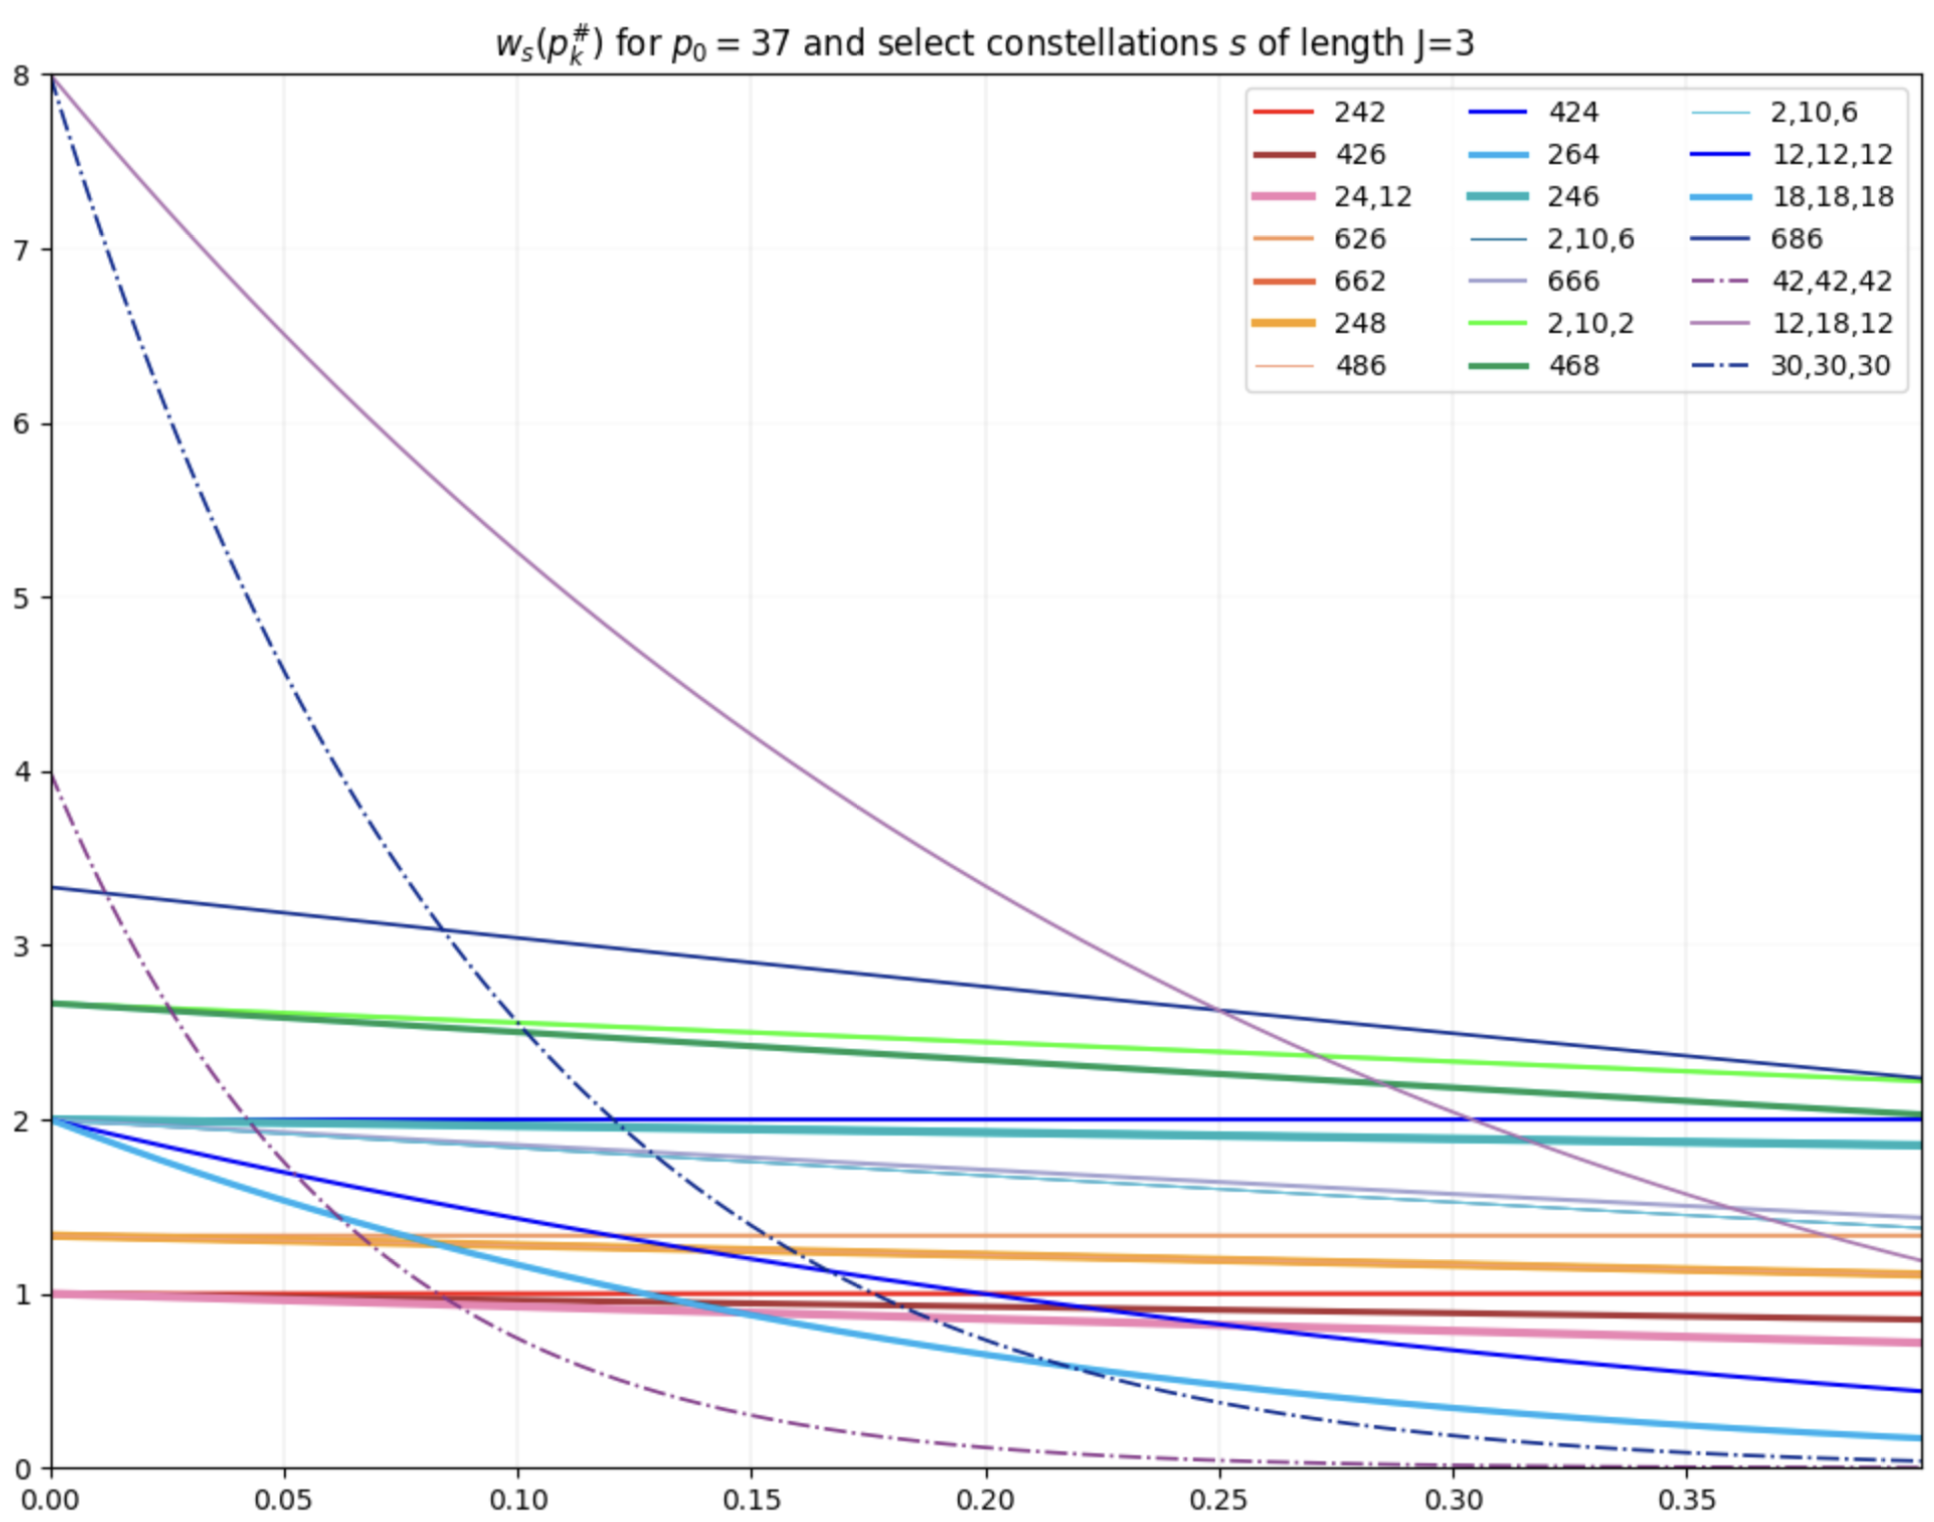

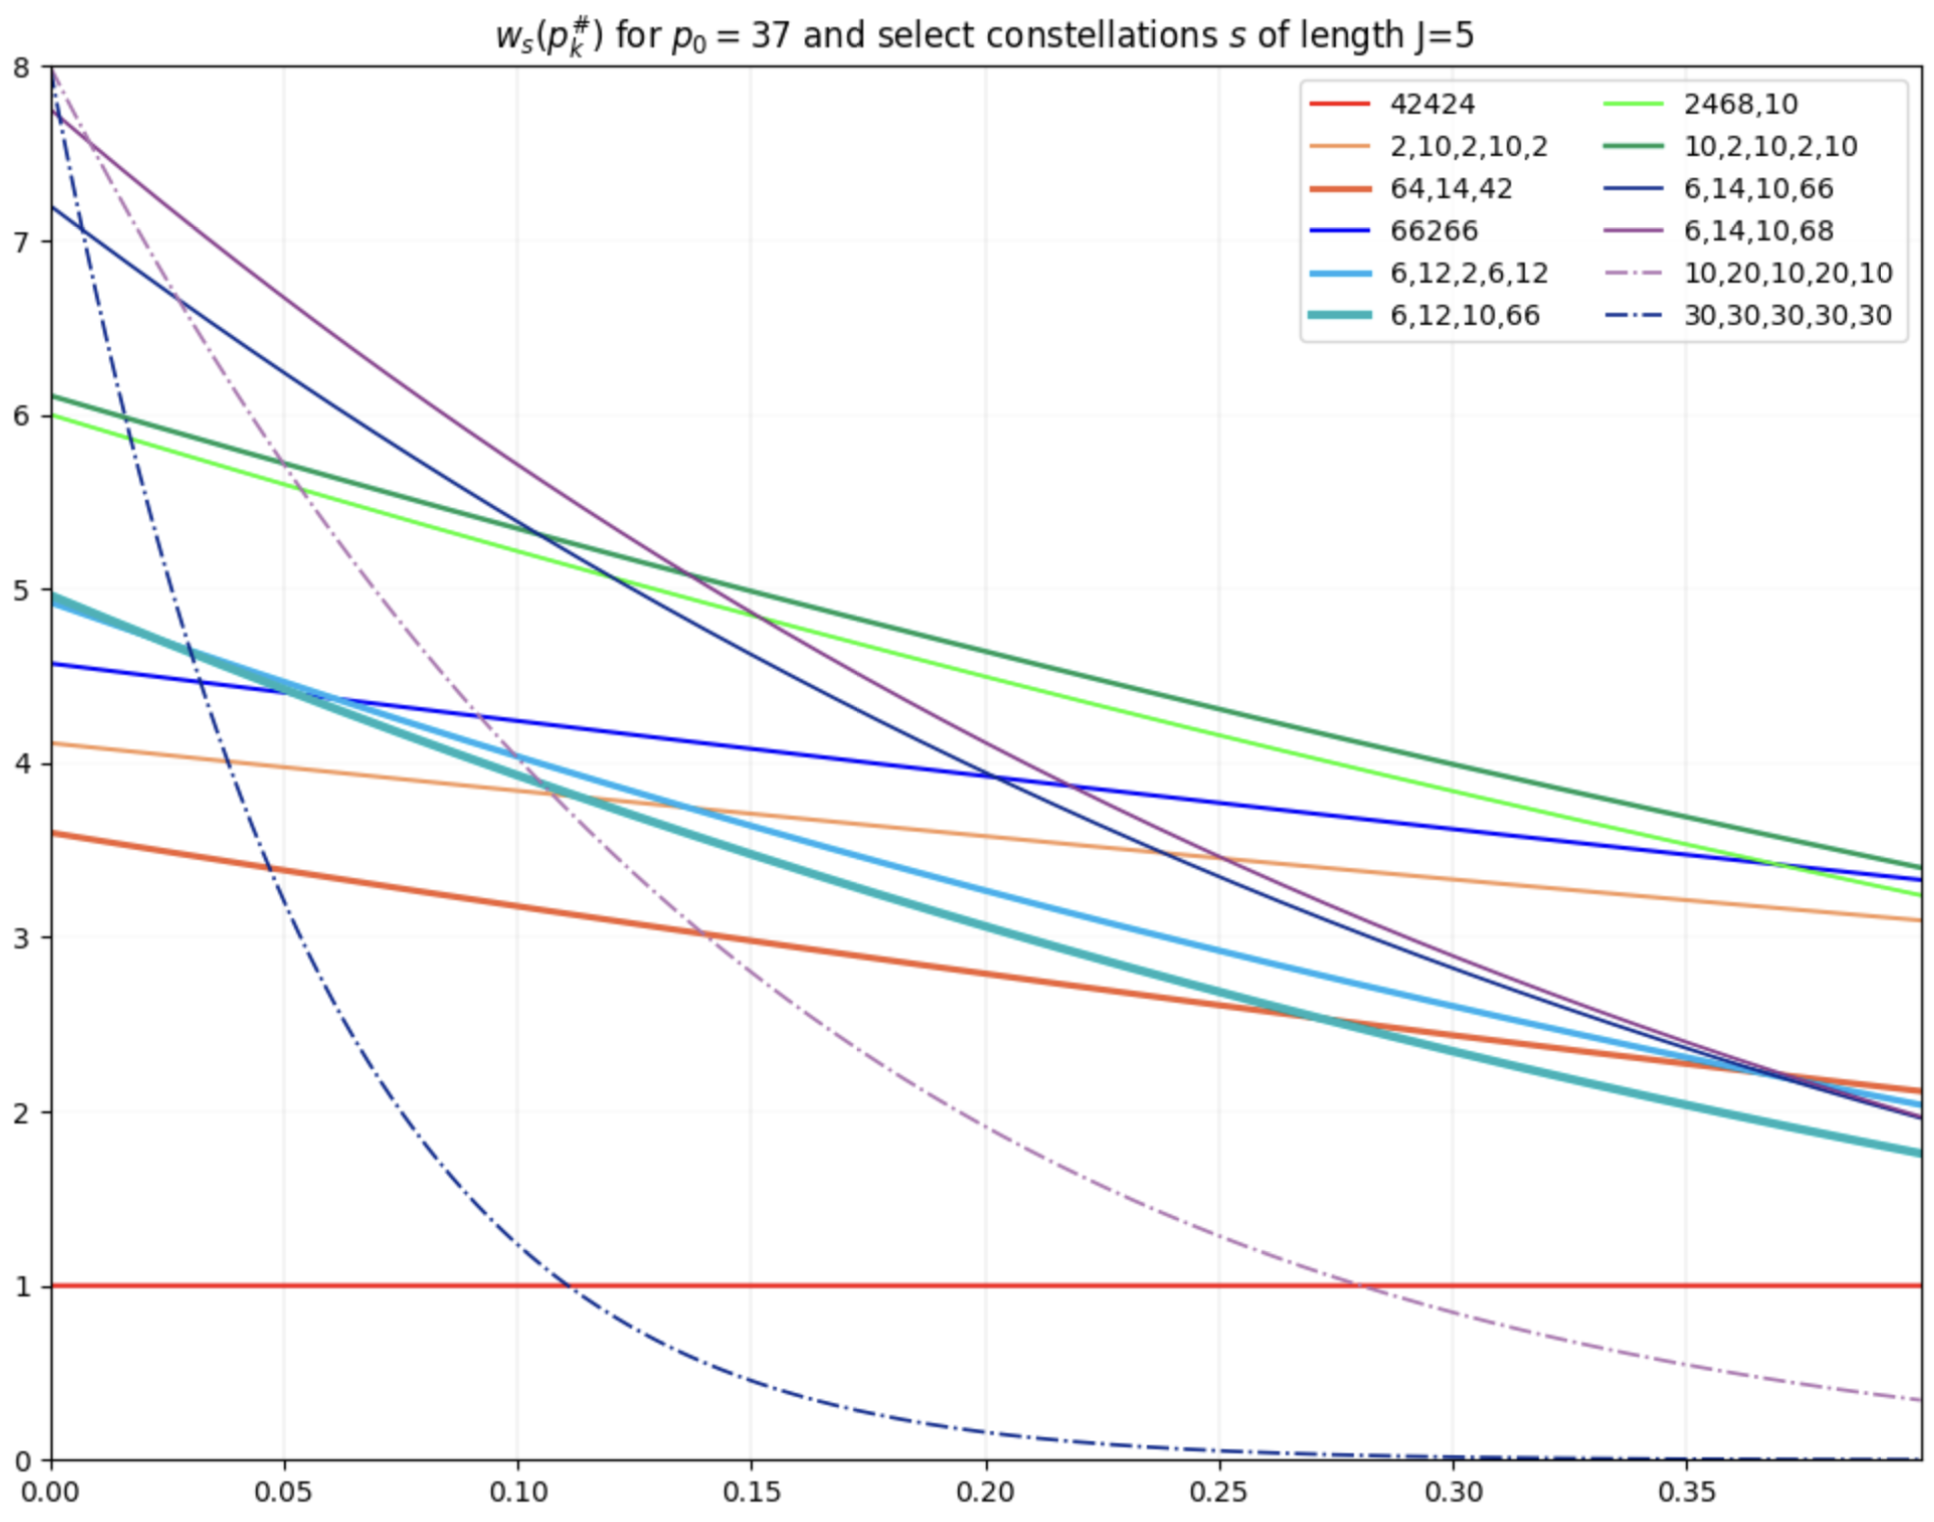

## Intervals of Survival $\Delta H(p)$
The interactive figure above displays the aggregation of gaps among primes by size of gap, across consecutive intervals of survival $\Delta H(p_k) = [p_k^2, p_{k+1}^2]$.

The aggregations of gaps within a single interval $\Delta H(p_k)$ appear as a colored band within the total displayed aggregation.  We color-code the band for $\Delta H(p_k)$ by the size of the gap $p_{k+1}-p_k$.

Two estimated levels from the models $w_g(\lambda)$ can be displayed:  the first-order and second-order estimates
based on an hypothesis of uniform distribution.

## Notes on samples of primes

| filename | num primes | $\min P$ | $\max P$ | $\# \Delta H$ | $\Delta H(p_0)$ | $\min P$ | $\Delta H(q_k)$ | $\max P$ |
| :--- | ---: | ---: | ---: | :---: | ---: | ---: | ---: | ---: |
| primeblockE09_360.npy | $55008596$ | $2400255059$ |$3600255031$ | $1021$ | $49003$ | $2401294057$ | $59981$ | $3599879993$ |
| primeblockE09_900.npy | $78902338$ | $7200254309$ |$9000254779$ | $881$ | $84857$ | $7200710471$ | $94847$ | $8996332747$ |
| primeblockE09_960.npy | $52355884$ | $8400254153$ |$9600254149$ | $557$ | $91673$ | $8403938941$ | $97967$ | $9598708711$ |
| primeblockE10_108.npy | $52072153$ | $9600254077$ | $10800254051$ | $506$ |$97987$ | $9601452193$|  $103913$ | $10799158553$ |
| primeblockE11_640.npy | $66214780$ | $6.400E11$ | $6.400E11$ | $94$ |$800011$ | $640017600137$|  $801103$ | $641772425447$ |
| primeblockE12_742.npy | $50612312$ | $7.421E12$ |$7.422E12$ | $18$ | $2724109$ | $7420769843911$ | $2724367$ | $7422230038127$ |
| primeblockE13_668.npy | $50267204$ | $6.679E13$ |$6.679E13$ | $7$ | $8172391$ | $66787974656917$ | $8172487$ | $66789543765101$ |
| primeblockE14_568.npy | $105954508$ | $5.677E14$ |$5.677E14$ | $7$ | $23826527$ | $567703388881771$ | $23826587$ | $567706819906781$ |
| primeblockE15_169.npy | $51337046$ | $1.694E15$ |$1.694E15$ | $1$ | $41161829$ | $1694296166625301$ | $41161829$ | $1694297813098769$ |
| primeblockE17_200.npy | $135549263$ | $2.00E17$ |$2.00E17$ | $2$ | $447216097$ | $200002237415913437$ | $447216101$ | $200002242782506531$ |
| primeblockE18_1046twin.npy | $130135262$ | $1.046E18$ | $1.046E18$ | $1$ |$1023094199$ | $1046721740027451601$|  $1023094201$ | $1046721744119828377$ |

